In [ ]:
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 521.2/521.2 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.6 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

dataset = load_dataset("gretelai/symptom_to_diagnosis")

Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['output_text', 'input_text'],
        num_rows: 853
    })
    test: Dataset({
        features: ['output_text', 'input_text'],
        num_rows: 212
    })
})

In [ ]:
train_texts, test_texts, train_labels, test_labels = dataset.['train']['input_text'],dataset.['test']['input_text'],dataset.['train']['output_text'],dataset.['test']['output_text']

SyntaxError: ignored

In [ ]:
possible_labels = train_labels.output_text.unique()

label_dict = {}
for index, possible_label in enumerate(possible_labels):
    label_dict[possible_label] = index
label_dict

AttributeError: ignored

In [ ]:
!pip install -q transformers

In [ ]:
!pip install pydot

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
from collections import Counter
import numpy as np
import tensorflow as tf
from tensorflow import keras

import seaborn as sns
import matplotlib.pyplot as plt
from pprint import pprint

In [ ]:
from transformers import BertTokenizer, TFBertModel

In [ ]:
len(test_texts)

120

In [ ]:
valid_texts = train_texts[:108].to_list()
valid_labels = train_labels[:108].to_numpy()
train_texts = train_texts[108:].to_list()
train_labels = train_labels[108:].to_numpy()
test_texts = test_texts.to_list()
test_labels = test_labels.to_numpy()

In [ ]:
def labels_to_int(data):
  out = []
  for lable in data:
    out.append(label_dict[lable])
  return out

train_labels = labels_to_int(train_labels)
test_labels = labels_to_int(test_labels)
valid_labels = labels_to_int(valid_labels)

In [ ]:
npvalid_labels = np.asarray(valid_labels)
train_labels = np.asarray(train_labels)
test_labels = np.asarray(test_labels)
valid_labels = np.asarray(valid_labels)

In [ ]:
#make it easier to use a variety of BERT subword models
model_checkpoint = 'bert-base-cased'

In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained(model_checkpoint)
bert_model = TFBertModel.from_pretrained(model_checkpoint)

tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [ ]:
max_length = 200

In [ ]:
# tokenize the dataset, truncate at `max_length`,
# and pad with 0's when less than `max_length` and return a tf Tensor
train_encodings = bert_tokenizer(train_texts, truncation=True, padding='max_length', max_length=200, return_tensors='tf')
valid_encodings = bert_tokenizer(valid_texts, truncation=True, padding='max_length', max_length=200, return_tensors='tf')
test_encodings = bert_tokenizer(test_texts, truncation=True, padding='max_length', max_length=200, return_tensors='tf')

In [ ]:
train_encodings.input_ids[:1]

<tf.Tensor: shape=(1, 200), dtype=int32, numpy=
array([[  101,   146,  4857, 26979,  1105,  1243,   185,  1883, 15901,
         2489,   119,  1247,  1110,  5411,  1892,  1107,  1139,   185,
         3051,   117,  1105,  1122,  5411,  1144,  1126,  7284,  1154,
         2879,  1895,   184,  2572,  2149,   119,   146,  5411,  1138,
         3819,  4058,  6153,  1272,  1104,  1139,  1940, 14867,  8515,
          119,   102,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0, 

In [ ]:
def create_bert_multiclass_model(checkpoint = model_checkpoint,
                                 num_classes = 24,
                                 hidden_size = 80,
                                 dropout=0.3,
                                 learning_rate=0.00005):
    """
    Build a simple classification model with BERT. Use the Pooler Output for classification purposes.
    """
    ### YOUR CODE HERE
    bert_model.trainable = True

    input_ids = tf.keras.layers.Input(shape=(max_length,), dtype=tf.int64, name='input_ids_layer')
    token_type_ids = tf.keras.layers.Input(shape=(max_length,), dtype=tf.int64, name='token_type_ids_layer')
    attention_mask = tf.keras.layers.Input(shape=(max_length,), dtype=tf.int64, name='attention_mask_layer')

    bert_inputs = {'input_ids': input_ids,
                   'token_type_ids': token_type_ids,
                   'attention_mask': attention_mask}

    bert_out = bert_model(bert_inputs)

    pooler_token = bert_out[1]

    hidden = tf.keras.layers.Dense(hidden_size, activation='relu', name='hidden_layer')(pooler_token)


    hidden = tf.keras.layers.Dropout(dropout)(hidden)


    classification = tf.keras.layers.Dense(num_classes, activation='softmax',name='classification_layer')(hidden)

    classification_model = tf.keras.Model(inputs=[input_ids, token_type_ids, attention_mask], outputs=[classification])

    classification_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                 loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                                 metrics='accuracy')

    ### END YOUR CODE
    return classification_model

In [ ]:
pooler_bert_model = create_bert_multiclass_model(checkpoint=model_checkpoint, num_classes=24)

In [ ]:
pooler_bert_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 attention_mask_layer (Inpu  [(None, 200)]                0         []                            
 tLayer)                                                                                          
                                                                                                  
 input_ids_layer (InputLaye  [(None, 200)]                0         []                            
 r)                                                                                               
                                                                                                  
 token_type_ids_layer (Inpu  [(None, 200)]                0         []                            
 tLayer)                                                                                      

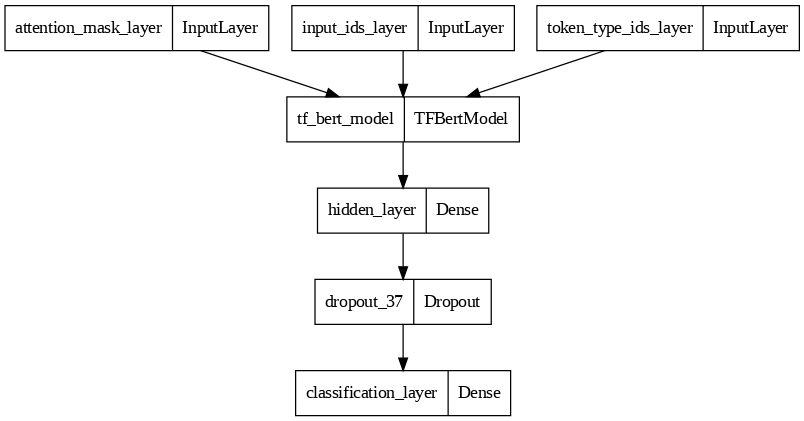

In [ ]:
keras.utils.plot_model(pooler_bert_model, show_shapes=False, show_dtype=False, show_layer_names=True, dpi=90)

In [ ]:
pooler_bert_model_history = pooler_bert_model.fit([train_encodings.input_ids, train_encodings.token_type_ids, train_encodings.attention_mask],
                                                  train_labels,
                                                  validation_data=([valid_encodings.input_ids, valid_encodings.token_type_ids, valid_encodings.attention_mask],
                                                  npvalid_labels),
                                                  batch_size=8,
                                                  epochs=10)

Epoch 1/10
122/122 [==============================] - 148s 383ms/step - loss: 2.5003 - accuracy: 0.2778 - val_loss: 1.3044 - val_accuracy: 0.7500
Epoch 2/10
122/122 [==============================] - 43s 356ms/step - loss: 0.8699 - accuracy: 0.7809 - val_loss: 0.4668 - val_accuracy: 0.8796
Epoch 3/10
122/122 [==============================] - 46s 373ms/step - loss: 0.3017 - accuracy: 0.9516 - val_loss: 0.1210 - val_accuracy: 0.9815
Epoch 4/10
122/122 [==============================] - 44s 362ms/step - loss: 0.1200 - accuracy: 0.9835 - val_loss: 0.1891 - val_accuracy: 0.9444
Epoch 5/10
122/122 [==============================] - 45s 369ms/step - loss: 0.0622 - accuracy: 0.9969 - val_loss: 0.0735 - val_accuracy: 0.9815
Epoch 6/10
122/122 [==============================] - 45s 369ms/step - loss: 0.0266 - accuracy: 1.0000 - val_loss: 0.0948 - val_accuracy: 0.9815
Epoch 7/10
122/122 [==============================] - 44s 361ms/step - loss: 0.0196 - accuracy: 1.0000 - val_loss: 0.0465 - val_a

In [ ]:
score = pooler_bert_model.evaluate([test_encodings.input_ids, test_encodings.token_type_ids, test_encodings.attention_mask],
                                                  test_labels)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

4/4 [==============================] - 2s 404ms/step - loss: 0.0271 - accuracy: 0.9917
Test loss: 0.027056684717535973
Test accuracy: 0.9916666746139526


In [ ]:
predictions = pooler_bert_model.predict([test_encodings.input_ids[:3], test_encodings.token_type_ids[:3], test_encodings.attention_mask[:3]])

1/1 [==============================] - 3s 3s/step


In [ ]:
predictions

array([[5.2443029e-05, 2.8773470e-06, 2.8568670e-06, 2.0914945e-06,
        2.5206993e-05, 4.4761217e-07, 3.1575699e-05, 8.4229532e-06,
        1.2419463e-06, 1.2460992e-05, 3.5388344e-05, 3.5270623e-05,
        1.9282374e-05, 2.3321120e-06, 5.5602759e-06, 9.9973327e-01,
        1.0174725e-06, 7.7569766e-06, 4.3502905e-06, 4.1275207e-06,
        5.9845879e-06, 3.2936605e-06, 2.4931232e-06, 1.8351089e-07],
       [9.9681702e-06, 2.9001078e-05, 8.7797061e-06, 1.7492473e-06,
        5.5351029e-05, 1.1000583e-06, 2.8612762e-05, 2.3907609e-05,
        4.4089788e-06, 5.0095659e-05, 2.9030132e-05, 2.0479569e-05,
        1.7835694e-06, 2.5621873e-06, 1.0285830e-05, 6.6053035e-05,
        5.3736538e-05, 9.9955159e-01, 3.5531318e-08, 2.4270810e-05,
        7.7963456e-08, 1.9666408e-05, 4.0437349e-06, 3.3418719e-06],
       [6.9157220e-05, 8.0321424e-06, 1.6734741e-05, 2.2412476e-06,
        2.3786220e-05, 2.3608682e-05, 2.2386710e-06, 6.5142058e-06,
        1.8904213e-06, 9.9909079e-01, 4.167734

In [ ]:
#run and capture all predictions from our test set using model.predict
### YOUR CODE HERE
predictions_model1 = pooler_bert_model.predict([test_encodings.input_ids, test_encodings.token_type_ids, test_encodings.attention_mask])
### END YOUR CODE

#now we need to get the highest probability in the distribution for each prediction
#and store that in a tf.Tensor
predictions_model1 = tf.argmax(predictions_model1, axis=-1)
predictions_model1

4/4 [==============================] - 2s 396ms/step


<tf.Tensor: shape=(120,), dtype=int64, numpy=
array([15, 17,  9, 15, 12, 23,  2, 22, 14, 19, 20, 23,  9,  5,  6, 17, 18,
        4, 13, 13,  8, 11, 16,  1,  0, 16, 18, 22, 19, 23, 15, 23, 15,  9,
       13, 18,  5,  5, 16, 14, 16, 10,  6,  6,  7, 22, 15,  7,  8, 20,  0,
        8,  3, 20, 10,  9,  9,  1,  7,  1, 15, 15, 17,  4, 12,  1,  6,  0,
        8,  9,  8, 18,  8, 10, 18, 19, 11, 12,  7, 20, 17, 17, 14, 11,  2,
       11, 16, 21,  2, 15, 10, 23,  5, 19,  3,  5,  7,  5,  6, 18, 17, 13,
       10, 21,  1, 22,  3, 10, 17, 15, 14,  8, 23, 12,  2,  3, 13, 11, 10,
       12])>

In [ ]:
print(classification_report(test_labels, predictions_model1.numpy(), target_names=list(label_dict.keys())))

                                 precision    recall  f1-score   support

                      Psoriasis       1.00      1.00      1.00         3
                 Varicose Veins       1.00      1.00      1.00         5
                        Typhoid       1.00      1.00      1.00         4
                    Chicken pox       1.00      1.00      1.00         4
                       Impetigo       1.00      1.00      1.00         2
                         Dengue       1.00      1.00      1.00         6
               Fungal infection       1.00      1.00      1.00         5
                    Common Cold       1.00      1.00      1.00         5
                      Pneumonia       1.00      1.00      1.00         7
          Dimorphic Hemorrhoids       1.00      1.00      1.00         6
                      Arthritis       1.00      1.00      1.00         7
                           Acne       1.00      1.00      1.00         5
               Bronchial Asthma       1.00      1.

Text(220.72222222222223, 0.5, 'True')

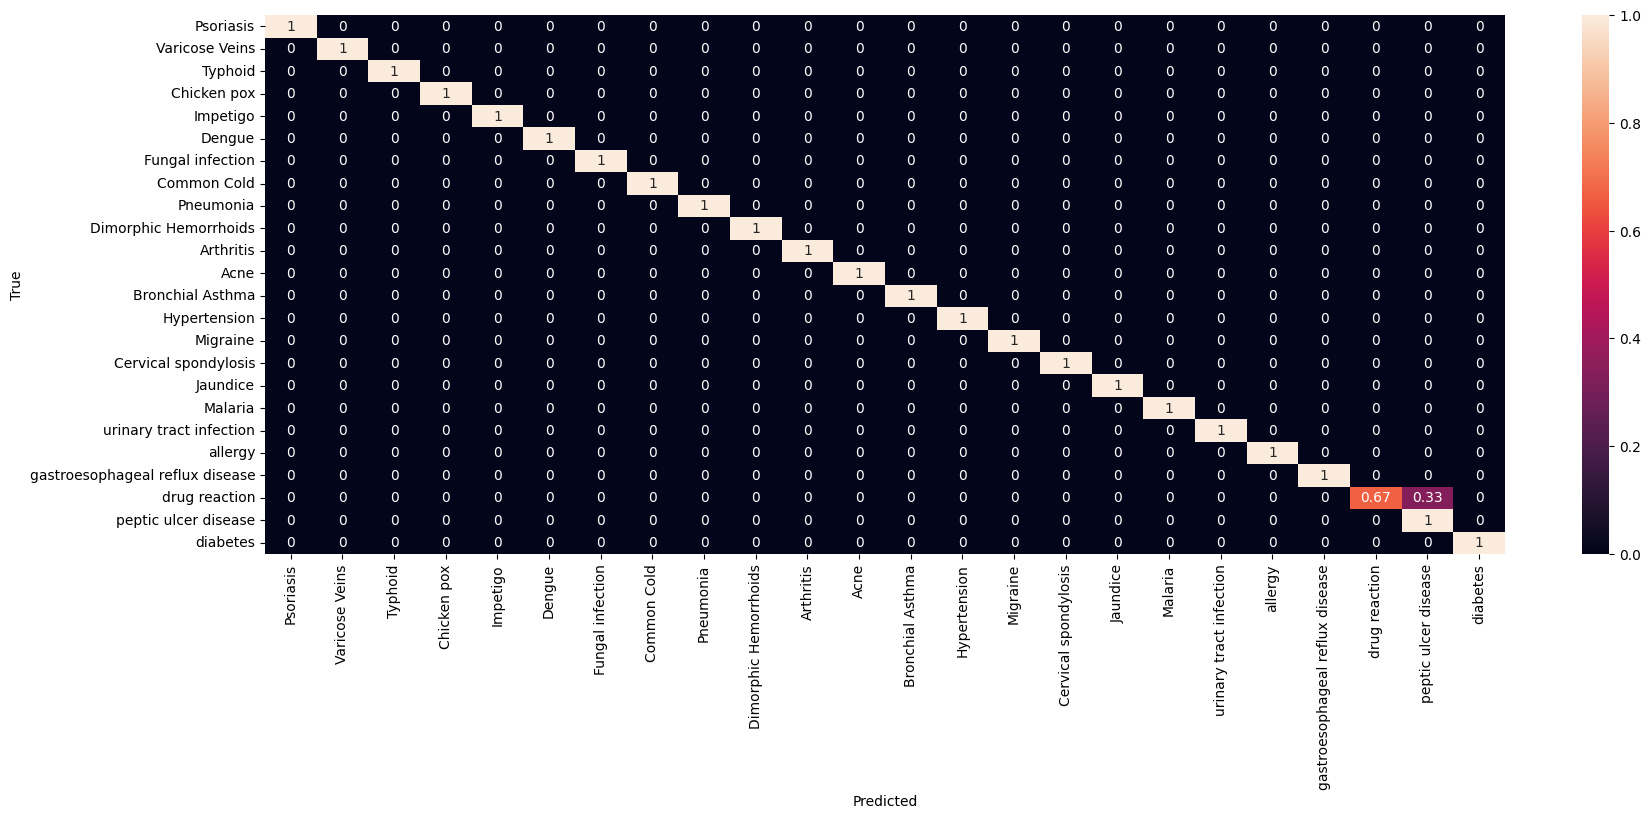

In [ ]:
cm = tf.math.confusion_matrix(test_labels, predictions_model1)
cm = cm/cm.numpy().sum(axis=1)[:, tf.newaxis]

plt.figure(figsize=(20,7))
sns.heatmap(
    cm, annot=True,
    xticklabels=list(label_dict.keys()),
    yticklabels=list(label_dict.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")

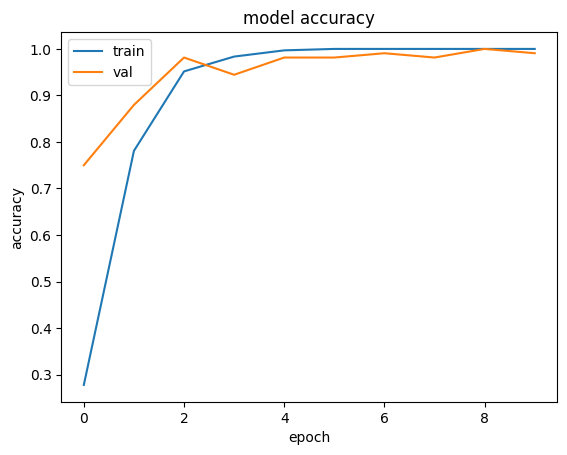

In [ ]:
from matplotlib import pyplot as plt
plt.plot(pooler_bert_model_history.history['accuracy'])
plt.plot(pooler_bert_model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

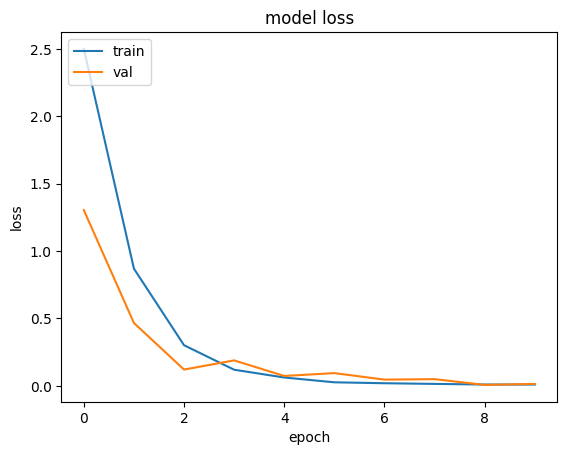

In [ ]:
plt.plot(pooler_bert_model_history.history['loss'])
plt.plot(pooler_bert_model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Knowledge Graph and BERT

In [ ]:
import re
import pandas as pd
import bs4
import requests
import spacy
from spacy import displacy
nlp = spacy.load('en_core_web_sm')

from spacy.matcher import Matcher
from spacy.tokens import Span

import networkx as nx

import matplotlib.pyplot as plt
from tqdm import tqdm

pd.set_option('display.max_colwidth', 200)
%matplotlib inline

In [ ]:
data = pd.read_csv('/content/dataset.csv')
data.head(5)
# kg_df = pd.DataFrame({'source':source, 'target':target, 'edge':relations})

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
diseases = data['Disease'].unique()
diseases

array(['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis',
       'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes ',
       'Gastroenteritis', 'Bronchial Asthma', 'Hypertension ', 'Migraine',
       'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice',
       'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia',
       'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins',
       'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia',
       'Osteoarthristis', 'Arthritis',
       '(vertigo) Paroymsal  Positional Vertigo', 'Acne',
       'Urinary tract infection', 'Psoriasis', 'Impetigo'], dtype=object)

In [ ]:
final = set()
for disease in diseases:
  new = set(data[data['Disease']==disease].drop('Disease',axis=1).values.flatten())
  for symp in new:
    symp = str(symp).strip()
    if symp == 'nan':
      continue
    if " _" in symp:
      symp = symp.replace(" _"," ")
    elif "_" in symp:
      symp = symp.replace("_"," ")
    final.add((str(symp).strip(),str(disease)))
sources = [node[0] for node in final]
targets = [node[1] for node in final]

In [ ]:
nodal_df = pd.DataFrame({'source':sources,'target':targets,'edge':'symptom of'})
#malaria = nodal_df[nodal_df['target'] == 'Malaria']

In [ ]:
G=nx.from_pandas_edgelist(nodal_df, "source", "target",
                          edge_attr=True, create_using=nx.MultiDiGraph())

In [ ]:
adj = nx.adjacency_matrix(G)
adj.shape

(172, 172)

In [ ]:
len(G.nodes())

172

In [ ]:
len(set(sources)) + len(set(diseases))

172

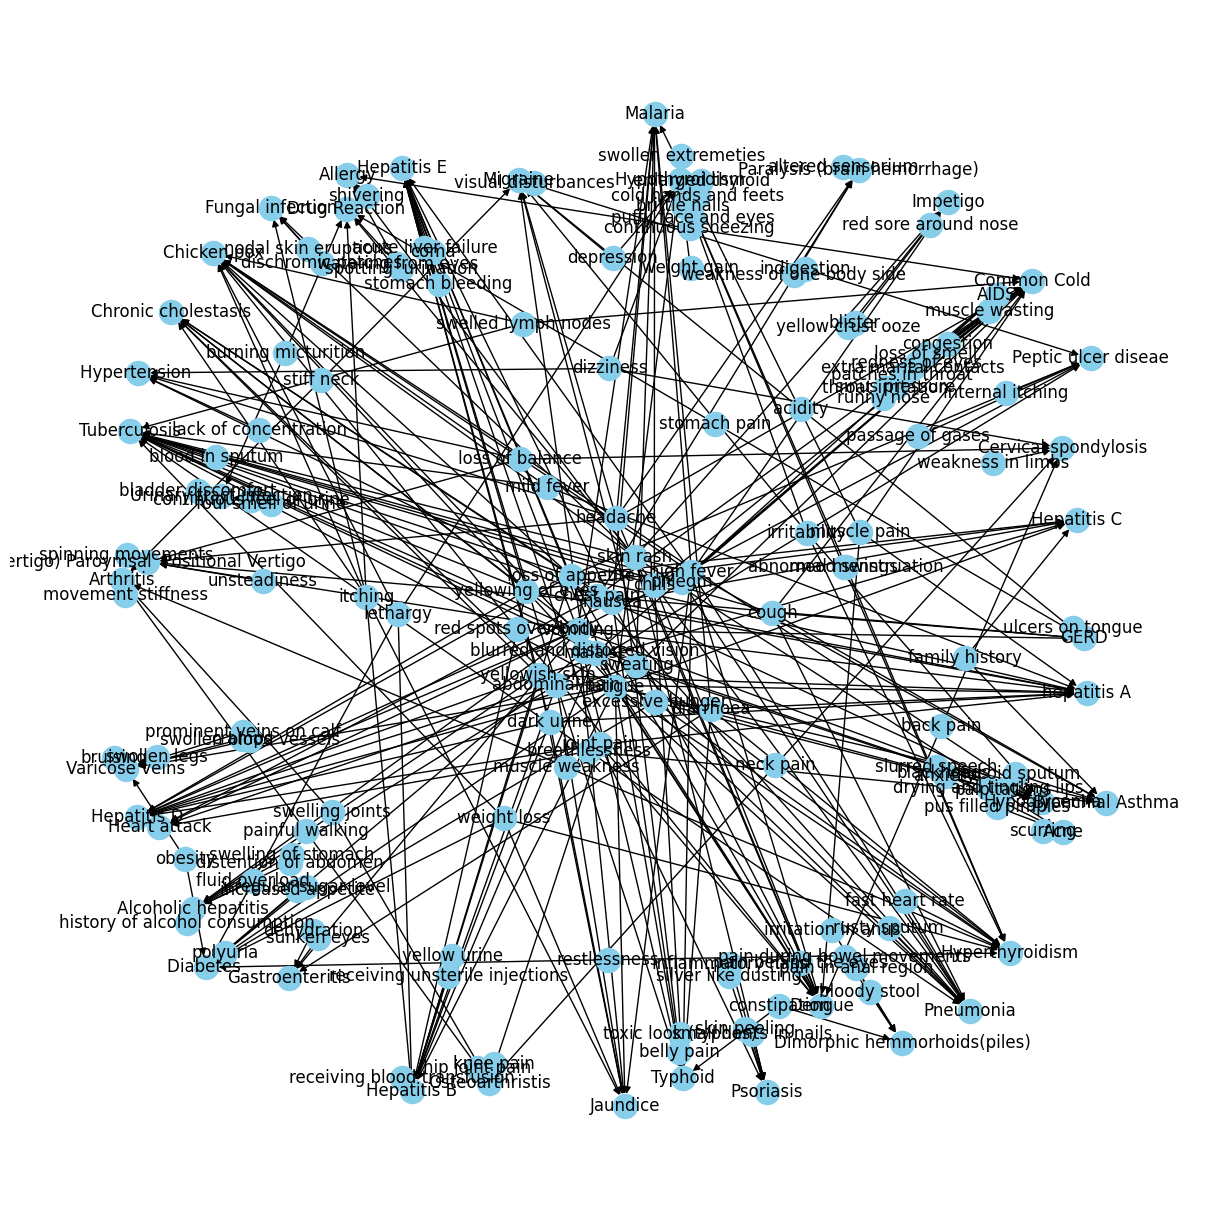

In [ ]:
plt.figure(figsize=(12,12))

pos = nx.spring_layout(G)
nx.draw(G, with_labels=True, node_color='skyblue', edge_cmap=plt.cm.Blues, pos = pos)
plt.show()

In [ ]:
from keras.models import Model
from keras.layers import Input, Dropout, Dense
from keras.optimizers import Adam
from spektral.layers import *

# Assuming you have the 'spektral' library installed (can be installed via pip install spektral)

# Create an adjacency matrix (adjacency_matrix) and node features (node_features)
# These are just placeholder values - you should replace them with your actual data

# Placeholder values
num_nodes = len(G.nodes())
num_features = 172
num_classes = len(diseases)

# Define the adjacency matrix (for simplicity, assuming an undirected graph)
adjacency_matrix = nx.adjacency_matrix(G)
  # Your adjacency matrix here

# Define node features
node_features = np.array([G.degree[node] for node in G.nodes()])  # Your node features here

# Input layer
X_in = Input(shape=(num_features,))

# Graph Convolutional Network (GCN) layer
graph_conv1 = GraphConv(32, activation='relu')([X_in, adjacency_matrix])

# Dropout for regularization
dropout = Dropout(0.5)(graph_conv1)

# Fully connected layer for classification
output_layer = Dense(num_classes, activation='softmax')(dropout)

# Create and compile the model
model = Model(inputs=X_in, outputs=output_layer)
model.compile(optimizer=Adam(lr=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Print a summary of the model architecture
model.summary()

# Assuming you have node labels for a node classification task
labels = [i for i in range(len(diseases))]  # Your node labels here (one-hot encoded for multi-class classification)

# Train the model
model.fit(node_features, labels, epochs=100, batch_size=1)


NameError: ignored

In [ ]:
!pip install spektral

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
df_train=pd.DataFrame(data=dataset['train'])
df_train.head()

,output_text,input_text
0,cervical spondylosis,I've been having a lot of pain in my neck and ...
1,impetigo,I have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...


In [ ]:
df_train.output_text.unique()

array(['cervical spondylosis', 'impetigo', 'urinary tract infection',
       'arthritis', 'dengue', 'common cold', 'drug reaction',
       'fungal infection', 'malaria', 'allergy', 'bronchial asthma',
       'varicose veins', 'migraine', 'hypertension',
       'gastroesophageal reflux disease', 'pneumonia', 'psoriasis',
       'diabetes', 'jaundice', 'chicken pox', 'typhoid',
       'peptic ulcer disease'], dtype=object)

In [ ]:
sorted_df = df_train.sort_values('output_text')

In [ ]:
possible_labels = sorted_df.output_text.unique()

label_dict = {}
for index, possible_label in enumerate(possible_labels):
    label_dict[possible_label] = index
label_dict

{'allergy': 0,
 'arthritis': 1,
 'bronchial asthma': 2,
 'cervical spondylosis': 3,
 'chicken pox': 4,
 'common cold': 5,
 'dengue': 6,
 'diabetes': 7,
 'drug reaction': 8,
 'fungal infection': 9,
 'gastroesophageal reflux disease': 10,
 'hypertension': 11,
 'impetigo': 12,
 'jaundice': 13,
 'malaria': 14,
 'migraine': 15,
 'peptic ulcer disease': 16,
 'pneumonia': 17,
 'psoriasis': 18,
 'typhoid': 19,
 'urinary tract infection': 20,
 'varicose veins': 21}

In [ ]:
df_test=pd.DataFrame(data=dataset['test'])
len(df_test['output_text'].unique())

22

In [ ]:
df_test.count() + df_train.count()

output_text    1065
input_text     1065
dtype: int64

In [ ]:
knowledge_graph = list(sorted_df.set_index('input_text').to_dict().values())[0]
answers = list(knowledge_graph.values())
labelled_graph = {}
for key,value in knowledge_graph.items():
  labelled_graph[key] = label_dict[value]

In [ ]:
answers = list(labelled_graph.values())
answers

0

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Sample data (replace this with your knowledge graph and Q&A pairs)
knowledge_graph = labelled_graph

# Preprocess data
questions = list(knowledge_graph.keys())
answers = list(knowledge_graph.values())

# Tokenize and vectorize questions using TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(questions)

# Function to get the most similar question from the knowledge graph
def get_most_similar_question(query):
    query_vector = vectorizer.transform([query])
    similarities = cosine_similarity(query_vector, X).flatten()
    most_similar_index = similarities.argmax()
    return questions[most_similar_index]

# Neural Network for generating responses
input_layer = Input(shape=(len(questions),))
embedding_layer = Embedding(input_dim=len(questions), output_dim=50)(input_layer)
lstm_layer = LSTM(100)(embedding_layer)
output_layer = Dense(len(answers), activation="softmax")(lstm_layer)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")
print(model.summary())
# Dummy labels for training (replace this with a more meaningful setup)
labels = np.asarray(answers)

# Train the model (replace this with a more meaningful setup)
model.fit(X, labels, epochs=10, batch_size=8, shuffle=True)

# Function to get a response from the neural network
# def get_nn_response(query):
#     query_index = questions.index(get_most_similar_question(query))
#     query_vector = vectorizer.transform([query])
#     return model.predict(query_vector)[0]

# # Example usage
# user_query = "What is Python programming language?"
# most_similar_question = get_most_similar_question(user_query)
# nn_response = get_nn_response(user_query)

# print("Most similar question from knowledge graph:", most_similar_question)
# print("Neural network response:", answers[nn_response.argmax()])

Model: "model_23"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_25 (InputLayer)       [(None, 849)]             0         
                                                                 
 embedding_24 (Embedding)    (None, 849, 50)           42450     
                                                                 
 lstm_24 (LSTM)              (None, 100)               60400     
                                                                 
 dense_23 (Dense)            (None, 849)               85749     
                                                                 
Total params: 188599 (736.71 KB)
Trainable params: 188599 (736.71 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


InvalidArgumentError: ignored